In [25]:
import torch
import matplotlib.pyplot as plt
import numpy as np

In [3]:
res = torch.load("/home/pb482/bott/results/GT_230.0_7.0_-3.0/EI/trial_1.pt",map_location=torch.device('cpu'))

In [49]:
best_obj = {}
mean_acqf_time = {}
std_acqf_time = {}
mean_best_obj = {}
std_best_obj = {}
upper_best_obj = {}
lower_best_obj ={}
for algo in ['EI','EICF','KG','TS']:
    best_obj[algo]={}
    acqf_time_temp=[]
    for trial in range(1,11):
        res = torch.load(f"/home/pb482/bott/results/GT_230.0_7.0_-3.0/{algo}/trial_{trial}.pt",map_location=torch.device('cpu'))
        best_obj_temp = [res['obj_func_val'][0]]
        acqf_time_temp.append([res['acqf_runtime'][0]])
        for iter in range(1,len(res['obj_func_val'])):
            best_obj_temp.append(max(best_obj_temp[-1],res['obj_func_val'][iter]))
            acqf_time_temp.append(res['obj_func_val'][iter])
        best_obj[algo][trial]= best_obj_temp
    mean_acqf_time[algo]=np.mean(acqf_time_temp)
    std_acqf_time[algo]=np.std(acqf_time_temp)
    mean_best_obj[algo] = [
        np.mean([-1*best_obj[algo][trial][iter] for trial in range(1, 11)])
        for iter in range(50)
    ]
    std_best_obj[algo] = [
        np.std([-1*best_obj[algo][trial][iter] for trial in range(1, 11)])
        for iter in range(50)
    ]
    upper_best_obj[algo]=[mean_best_obj[algo][iter]+1.96*std_best_obj[algo][iter] for iter in range(50)]
    lower_best_obj[algo]=[mean_best_obj[algo][iter]-1.96*std_best_obj[algo][iter] for iter in range(50)]

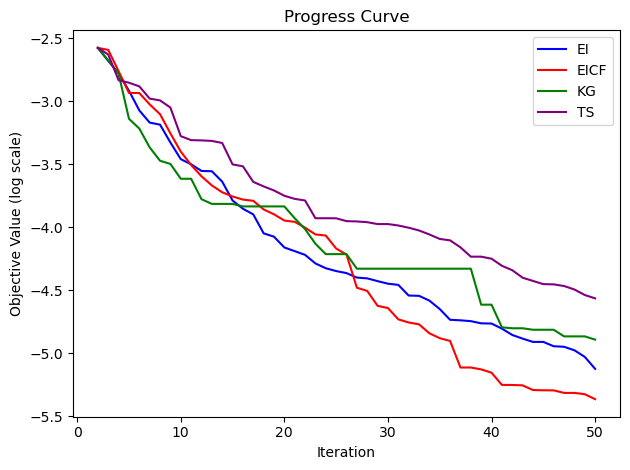

In [57]:
plt.plot(list(range(2,51)), np.log(mean_best_obj['EI'][1:]), label='EI', color='blue')
# plt.fill_between(list(range(2,51)), np.log(lower_best_obj['EI'][1:]), np.log(upper_best_obj['EI'][1:]), color='blue', alpha=0.1)
plt.plot(list(range(2,51)), np.log(mean_best_obj['EICF'][1:]), label='EICF', color='red')
# plt.fill_between(list(range(2,51)), np.log(lower_best_obj['EICF'][1:]), np.log(upper_best_obj['EICF'][1:]), color='red', alpha=0.1)
plt.plot(list(range(2,51)), np.log(mean_best_obj['KG'][1:]), label='KG', color='green')
# plt.fill_between(list(range(2,51)), np.log(lower_best_obj['KG'][1:]), np.log(upper_best_obj['KG'][1:]), color='green', alpha=0.1)
plt.plot(list(range(2,51)), np.log(mean_best_obj['TS'][1:]), label='TS', color='purple')
# plt.fill_between(list(range(2,51)), lower_best_obj['TS'][1:], upper_best_obj['TS'][1:], color='purple', alpha=0.1)
plt.xlabel('Iteration')
plt.ylabel('Objective Value (log scale)')
plt.title('Progress Curve')
plt.legend()
plt.tight_layout()
plt.show()